# Challenge $0$


## 1. ***Data cleaning with Pandas***

Use the library `pandas` to load and clean the required dataset.

In [313]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import numpy.linalg as LA

Obtain the data file

In [314]:
FFILE = './50_Startups.csv'
if os.path.isfile(FFILE):
    print("File already exists")
    if os.access(FFILE, os.R_OK):
        print ("File is readable")
    else:
        print ("File is not readable, removing it and downloading again")
        !rm FFILE
        !curl -o "50_Startups.csv" "https://raw.githubusercontent.com/alexdepremia/ML_IADA_UTs/refs/heads/main/challenge_0/50_Startups.csv"
else:
    print("Either the file is missing or not readable, download it")
    !curl -o "50_Startups.csv" "https://raw.githubusercontent.com/alexdepremia/ML_IADA_UTs/refs/heads/main/challenge_0/50_Startups.csv"

File already exists
File is readable


In [315]:
import pandas as pd

# Load the dataset using Pandas
data = pd.read_csv('50_Startups.csv')

# Extracting the features (independent variables) and labels (dependent variable)
# Features (X) are taken from all columns except the last two
features = data.iloc[:, :-2].values

# Labels (y) are taken from the third column (index 3, considering the 0-based index in Python)
labels = data.iloc[:, 3].values

df = pd.DataFrame(data)

In [316]:
labels

array(['New York', 'California', 'Florida', 'New York', 'Florida',
       'New York', 'California', 'Florida', 'New York', 'California',
       'Florida', 'California', 'Florida', 'California', 'Florida',
       'New York', 'California', 'New York', 'Florida', 'New York',
       'California', 'New York', 'Florida', 'Florida', 'New York',
       'California', 'Florida', 'New York', 'Florida', 'New York',
       'Florida', 'New York', 'California', 'Florida', 'California',
       'New York', 'Florida', 'California', 'New York', 'California',
       'California', 'Florida', 'California', 'New York', 'California',
       'New York', 'Florida', 'California', 'New York', 'California'],
      dtype=object)

***Play with data***

In [317]:
df.shape

(50, 5)

In [318]:
df.replace(to_replace = 0.00, value = df.mean(axis=0, numeric_only=True), inplace=True)  # inject the mean of the column when value is 0
df.head()

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


 **`df.replace()` function:**
   - This function is used to replace specific values within a DataFrame (`df`) with another value.
   - The parameters used are:
     - `to_replace=0.00`: This specifies the value in the DataFrame that needs to be replaced, in this case, `0.00`.
     - `value=df.mean(axis=0)`: This sets the replacement value for the matched condition. Here, `df.mean(axis=0)` calculates the mean for each column along the rows (axis=0) of the DataFrame `df`. The mean value for each column will replace the `0.00` values.
     - `inplace=True`: This parameter ensures that the modification is done directly on the original DataFrame (`df`) without creating a new DataFrame. If `inplace` is set to `True`, the original DataFrame is modified.

***Select two categories for binary classification***

In [319]:
df_sel=df[(df.State=="California") | (df.State=="Florida")]

In [320]:
df_sel.head() # column title and first rows of the dataset

,R&D Spend,Administration,Marketing Spend,State,Profit
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
4,142107.34,91391.77,366168.42,Florida,166187.94
6,134615.46,147198.87,127716.82,California,156122.51
7,130298.13,145530.06,323876.68,Florida,155752.60


In [321]:
df_sel.dtypes # type of each column

R&D Spend          float64
Administration     float64
Marketing Spend    float64
State               object
Profit             float64
dtype: object

***Encode categorical data***

One-hot encoding of categorical feature _State_

One-Hot Encoding is a technique used in machine learning to handle categorical variables by transforming them into a format that can be easily utilized by algorithms.

Imagine having a categorical variable, such as colors: red, green, and blue. With One-Hot Encoding, each color becomes a new binary column. If an observation has a specific color, the column corresponding to that color will be set to 1, while the other columns will be set to 0.

For example:
- If you have categories "red", "green", "blue", and you want to encode them using One-Hot Encoding:
  - "red" becomes [1, 0, 0]
  - "green" becomes [0, 1, 0]
  - "blue" becomes [0, 0, 1]

This helps machine learning algorithms to understand and work with these categorical variables more effectively, as it doesn't impose an order or hierarchy among the categories but rather represents them in a form that the algorithm can interpret more efficiently.

In [322]:
df_one = pd.get_dummies(df_sel["State"], dtype=int)

In [323]:
df_one.head()

,California,Florida
1,1,0
2,0,1
4,0,1
6,1,0
7,0,1


In [324]:
# Constructing the final dataset for learning and prediction

# Concatenating two DataFrames 'df_one' and 'df_sel' along columns (axis=1)
df_fin = pd.concat((df_one, df_sel), axis=1)

# Dropping the column "Florida" from the dataset as it was not selected for the final model
df_fin = df_fin.drop(["Florida"], axis=1)

# Dropping the column "State" (assumed to be the original 'State' column) as it is not required in its original form
df_fin = df_fin.drop(["State"], axis=1)

# Renaming the column "California" to "State" as part of preparing the dataset for classification (1 for California, 0 for Florida)
df_fin = df_fin.rename(columns={"California": "State"})

# Displaying the initial rows of the modified final dataset
df_fin.head()

,State,R&D Spend,Administration,Marketing Spend,Profit
1,1,162597.70,151377.59,443898.53,191792.06
2,0,153441.51,101145.55,407934.54,191050.39
4,0,142107.34,91391.77,366168.42,166187.94
6,1,134615.46,147198.87,127716.82,156122.51
7,0,130298.13,145530.06,323876.68,155752.60


***Normalize***

Divide by the absolute value of the maximum so that features are in \[0, 1\]

In [325]:
def absolute_maximum_scale(series):
    """
    Scale each column in the DataFrame 'df_fin' by dividing the values by the absolute maximum value of that column.

    Args:
    series: A pandas Series or DataFrame column to be scaled.

    Returns:
    A scaled version of the input series with values ranging from -1 to 1 based on the maximum absolute value in the column.
    """
    return series / series.abs().max()

In [326]:
# Apply the 'absolute_maximum_scale' function to each column in the DataFrame 'df_fin'
for col in df_fin.columns:
    df_fin[col] = absolute_maximum_scale(df_fin[col])

In [327]:
df_fin.head()

,State,R&D Spend,Administration,Marketing Spend,Profit
1,1.0,1.000000,0.828805,1.000000,1.000000
2,0.0,0.943688,0.553781,0.918982,0.996133
4,0.0,0.873981,0.500378,0.824892,0.866501
6,1.0,0.827905,0.805926,0.287716,0.814020
7,0.0,0.801353,0.796789,0.729619,0.812091


In [328]:
df_fin.shape

(33, 5)

***Classification***

Prepare the dataset:

In [329]:
y = df_fin["State"] # ground truth labels
X = df_fin.drop(["State"], axis=1) # datapoints features
# extract actual values from series
y = y.values
X = X.values

Train test split

$75\%$ of the data are in the training set, the remaining $25\%$ constitutes the test set.

In [330]:
from sklearn.model_selection import train_test_split

# Splitting the dataset into training and testing sets
# X represents the features (independent variables), and y represents the target (dependent variable).

# Using train_test_split function to create the training and testing sets
# X_train and y_train: Training features and labels
# X_test and y_test: Testing features and labels

# The 'test_size=0.25' parameter sets the proportion of the dataset to include in the test split. Here, 25% of the data is allocated to the test set.
# The 'random_state=0' parameter sets the random seed for reproducibility of the split.

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0, stratify= y)


Train the Logistic Regression Model

In [331]:
from sklearn.linear_model import LogisticRegression

In [332]:
# Creating a Logistic Regression model with specific parameters
# - 'random_state=0' ensures reproducibility by setting the random seed.
# - 'solver='lbfgs'' selects the optimization algorithm for the logistic regression.

LR = LogisticRegression(random_state=0, solver='lbfgs').fit(X_train, y_train)

# Predicting the target variable (y) using the Logistic Regression model on the test set (X_test).
predictions = LR.predict(X_test)

# Calculating and rounding the accuracy score of the Logistic Regression model on the test set.
# The score is calculated by comparing the predicted values to the actual values (y_test).
accuracy = round(LR.score(X_test, y_test), 4)


***Plot results***



In [333]:
from sklearn.metrics import confusion_matrix

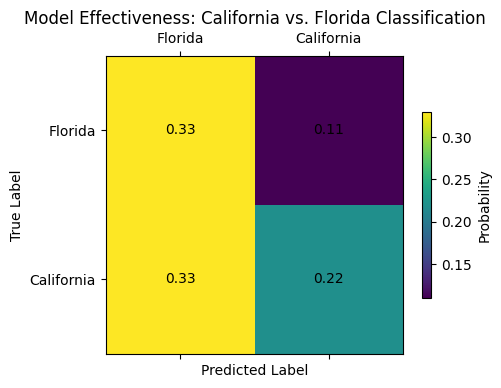

In [334]:
cm = confusion_matrix(y_test, y_pred = predictions)
labels = ["Florida", "California"]

t = np.sum(cm)
cm_prob = np.round(cm/t,2)
plt.matshow(cm_prob)
cb = plt.colorbar(shrink=0.5)
plt.title("Model Effectiveness: California vs. Florida Classification")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
cb.set_label("Probability")
plt.xticks([0,1], labels)
plt.yticks([0,1], labels)


for i in range(len(labels)):
    for j in range(len(labels)):
        plt.text(j,i,cm_prob[i,j], ha='center', va='center', color='black')

***Add regularization***

Implement from scratch the regularized logistic regression model (with all the regularization techniques seen during the course).

In [335]:
###############################
#      Funzione Sigmoide      #
###############################
def sigmoidM(x, w):
    """
    Parameters
    ----------
    x : array of dim n
        Array containing the datapoint
    w : float
        Number representing the 'temperature' of the sigmoid
    """
    y = 1/(1 + np.exp(-np.dot(x,w)))

    # Clipping per la stabilità numerica
    epsilon = 1e-6

    # Aggancia l'output in modo che non sia MAI 0 o 1
    return np.clip(y, epsilon, 1 - epsilon)

###############################
#      Logistic Loss          #
###############################
def LogisticLoss(X, labels, w):
    """
    Parameters
    ----------
    X : array of dim n x d
        Matrix containing the dataset
    y : array of dim n
        Vector representing the ground truth label of each data point
    w : array of dim d
        Vector representing the coefficients of the logistic model
    """
    n = np.shape(X)[0]
    cost = -(1/n)*np.sum(labels*np.log(sigmoidM(X,w)) + (1-labels)*np.log(1-sigmoidM(X,w)))
    return cost

###############################
#      Gradient descend       #
###############################
def GDLogistic(X, labels, iter, gamma):
    """
    Parameters
    ----------
    X : array of dim n x d
        Matrix containing the dataset
    labels : array of dim n
        Vector representing the ground truth label of each data point
    iter : int
        Number of GD iterations
    gamma : float
        Learning rate
    """
    d = np.shape(X)  # d contains the shape of X, which is a tuple (n, d)
    cost = np.zeros(iter)  # Create an array to store the cost at each iteration
    w = np.random.uniform(0, 0.01, d[1])  # Initialize w with random values
    W = np.zeros((2, iter))  # Create an array to store the weight vectors at each iteration

    for i in range(iter):
        W[:, i] = w  # Store the current weight vector in the W array
        # Update the weight vector using gradient descent
        w = w - (2 * gamma / d[0]) * (np.transpose(X) @ (sigmoidM(X, w) - labels))
        # Compute and store the logistic loss for the current weight vector
        cost[i] = LogisticLoss(X, labels, w)

    return W, cost

###############################
#         Ridge               #
###############################


def LogisticRidgeLoss(X, y, w, lam):
    """
    Parameters
    ----------
    X : array of float dim n x d
        Matrix containing the dataset
    y : array of float of dim n
        Vector containing the ground truth value of each data point
    w : array of float of dim d
        Weights of the fitted line
    lam : float
        Weight of the L2 penalty term
    """

    # 1. Costo Logistico (Log Loss)
    logistic_cost = LogisticLoss(X, y, w)

    # 2. Penalità L2 (lam * ||w||^2)
    l2_penalty = lam * np.dot(w, w)

    # 3. Costo Totale
    return logistic_cost + l2_penalty

def LogisticGradient(X, labels, w, points):
    """
    Calcola il gradiente della funzione di costo logistico (Log Loss).
    """
    # La parte di errore (h(x,w) - y) trasposta e moltiplicata per X,
    # poi normalizzata per il numero di punti.
    return (1 / points) * (np.transpose(X) @ (sigmoidM(X, w) - labels))

def RidgeGradient(w, lam):
    grad = 2 * lam * w
    grad[0] = 0 # Non penalizzare l'intercetta
    return grad

def GDLogisticRidge(X, y, iter, gamma, points, d, lam):
    """
    Gradient Descent per la Regressione Logistica L2 (Ridge).
    """
    W = np.zeros((d, iter))
    L = np.zeros(iter)
    w = np.zeros(d) # Inizializzazione a zero per i pesi

    for i in range(iter):
        W[:, i] = w

        # Gradiente Totale = Gradiente Logistico + Gradiente L2 (Ridge)
        logistic_grad = LogisticGradient(X, y, w, points)
        ridge_grad = RidgeGradient(w, lam)
        total_grad = logistic_grad + ridge_grad

        # AGGIORNAMENTO DEI PESI: w = w - gamma * Gradiente Totale
        w = w - gamma * total_grad

        # Calcolo del costo totale per monitorare l'andamento
        L[i] = LogisticRidgeLoss(X, y, w, lam)

    return W, L, w # Aggiunto w finale per la predizione

#########################
#        Lasso          #
#########################

def LogisticLassoLoss(X, y, w, lam):
    """
    Parameters
    ----------
    X : array of float dim n x d
        Matrix containing the dataset
    y : array of float of dim n
        Vector containing the ground truth value of each data point
    w : array of float of dim d
        Weights of the fitted line
    lam : float
        Weight of the L1 penalty term
    """

    # 1. Costo Logistico (Log Loss)
    logistic_cost = LogisticLoss(X, y, w)

    # 2. Penalità L2 (lam * ||w||^2)
    l1_penalty = lam * LA.norm(w, 1)

    # 3. Costo Totale
    return logistic_cost + l1_penalty

def L1_subgradient(z):
    g = np.ones(z.shape)
    g[z < 0.] = -1.0
    return g

def LassoGradient(w, lam):
    return lam * L1_subgradient(w)

def GDLogisticLasso(X, y, iter, gamma, points, d, lam):
    """
    Gradient Descent per la Regressione Logistica L1 (Lasso).

    Parameters
    ----------
    X : array of float dim n x d
        Matrice contenente il dataset.
    y : array of float of dim n
        Vettore contenente le etichette reali (ground truth).
    iter : int
        Numero di iterazioni di GD.
    gamma : float
        Learning rate.
    points : int
        Numero di data point (punti).
    d : int
        Dimensionalità (numero di feature).
    lam : float
        Peso del termine di penalità L1.
    """
    W = np.zeros((d, iter))
    L = np.zeros(iter)
    w = np.random.normal(0, 0.1, d) # Inizializzazione casuale dei pesi

    for i in range(iter):
        W[:, i] = w

        # 1. Calcola il Gradiente Logistico (derivata del costo)
        logistic_grad = LogisticGradient(X, y, w, points)

        # 2. Calcola il Gradiente Lasso (derivata della penalità L1)
        # Uso funzione LassoGradient
        lasso_grad = LassoGradient(w, lam)

        # 3. AGGIORNAMENTO CHIAVE DEI PESI: w = w - gamma * (Gradiente Logistico + Gradiente Lasso)
        total_grad = logistic_grad + lasso_grad
        w = w - gamma * total_grad

        # 4. Calcolo del costo totale (LogisticLoss + Penalità L1)
        L[i] = LogisticLassoLoss(X, y, w, lam)

    return W, L, w # Aggiunto w finale per la predizione

###################
#   Elastic Net   #
###################
def ElasticNetLoss(X, y, w, lr, l):
    """
    Calcola la loss Elastic Net (LogLoss + L1 + L2-squared).
    """
    costo_logistico = LogisticLoss(X, y, w)

    # Penalità L1
    l1_penalty = lr * l * LA.norm(w, 1)

    # Penalità L2 (al quadrato)
    # USA np.dot(w, w) COME PER RIDGE
    l2_penalty = (1 - lr) * l * np.dot(w, w)

    return costo_logistico + l1_penalty + l2_penalty

# Elastic Net Gradient Function
def ElasticNetGradient(X, y, w, lr, l, points):
    """
    Calculate the gradient for Elastic Net regularization.

    Parameters
    ----------
    X : array of float dim n x d
        Matrix containing the dataset.
    y : array of float of dim n
        Vector containing the ground truth value of each data point.
    w : array of float of dim d
        Weights of the fitted line.
    lr : float
        Convex combination parameter (controls L1 vs. L2 regularization).
    l : float
        Regularization strength parameter.
    points : int
        Number of data points.

    Returns
    -------
    gradient : array of float of dim d
        Gradient of the Elastic Net regularization term.
    """
    return LogisticGradient(X, y, w, points) + (1 - lr) * RidgeGradient(w, l) + lr * LassoGradient(w, l)

# Gradient Descent with Elastic Net Regularization
def GDElasticNet(X, y, lr, l, iter, gamma):
    """
    Perform Gradient Descent with Elastic Net regularization for log regression.

    Parameters
    ----------
    X : array of float dim n x d
        Matrix containing the dataset.
    y : array of float of dim n
        Vector containing the ground truth value of each data point.
    lr : float
        Convex combination parameter (controls L1 vs. L2 regularization).
    l : float
        Regularization strength parameter.
    iter : int
        Number of GD iterations.
    gamma : float
        Learning rate.

    Returns
    -------
    W : array of float of dim d x iter
        Weight vectors at each iteration.
    L : array of float of dim iter
        Loss values at each iteration.
    """
    points = X.shape[0]
    d = X.shape[1]
    W = np.zeros((d, iter))
    L = np.zeros(iter)
    w = np.random.normal(0, 0.1, d)
    for i in range(iter):
        W[:, i] = w
        w = w - gamma * ElasticNetGradient(X, y, w, lr, l, points)
        L[i] = ElasticNetLoss(X, y, w, lr, l)
    return W, L, w

### Training

In [336]:

d = X_train.shape[1]
points = X_train.shape[0]
iter = 10000
iter_i = 10000
gamma_r = 0.00000001
gamma_l = 0.00000001
gamma_e = 0.00000001
lam = 0.1
lr = 0.5

##################
# Logistic Ridge #
##################
W_r, L_r, w_r = GDLogisticRidge(X_train, y_train, iter, gamma_r, points, d, lam)

##################
# Logistic Lasso #
##################
W_l, L_l, w_l = GDLogisticLasso(X_train, y_train, iter_i, gamma_l, points, d, lam)

########################
# Logistic Elastic Net #
########################
W_e, L_e, w_e = GDElasticNet(X_train, y_train, lr, lam, iter_i, gamma_e)

***Model assessment***

Given true and predicted values, compute the most common classification metrics to assess the quality of your predictions.

In [337]:
from sklearn.metrics import classification_report
y_true = y_test
y_pred = LR.predict(X_test)

target_names = ['Florida', 'California'] # 0 = Florida, 1 = California
report = classification_report(y_true, y_pred, target_names=target_names, output_dict=True)
report_df = pd.DataFrame(report)
report_df.head()

,Florida,California,accuracy,macro avg,weighted avg
precision,0.50,0.666667,0.555556,0.583333,0.592593
recall,0.75,0.400000,0.555556,0.575000,0.555556
f1-score,0.60,0.500000,0.555556,0.550000,0.544444
support,4.00,5.000000,0.555556,9.000000,9.000000


Repeat the previous task for regularized logistic regression and compare the results.

In [338]:
##################
# Logistic Ridge #
##################
prob_r = sigmoidM(X_test, w_r)
y_pred_r = (prob_r<0.5).astype(int)

##################
# Logistic Lasso #
##################
prob_l = sigmoidM(X_test, w_l)
y_pred_l = (prob_l < 0.5).astype(int)

########################
# Logistic Elastic Net #
########################
prob_e = sigmoidM(X_test, w_e)
y_pred_e = (prob_e < 0.5).astype(int)

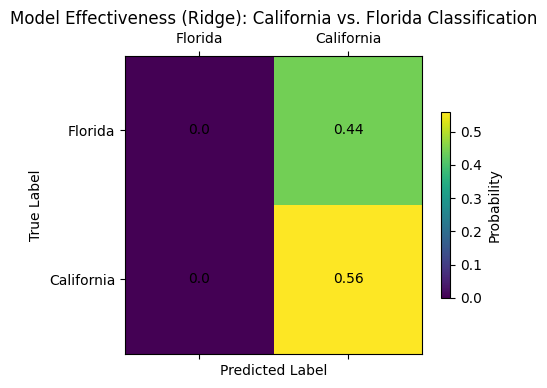

In [339]:
cm = confusion_matrix(y_test, y_pred = y_pred_r)
labels = ["Florida", "California"]

t = np.sum(cm)
cm_prob = np.round(cm/t,2)
plt.matshow(cm_prob)
cb = plt.colorbar(shrink=0.5)
plt.title("Model Effectiveness (Ridge): California vs. Florida Classification")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
cb.set_label("Probability")
plt.xticks([0,1], labels)
plt.yticks([0,1], labels)


for i in range(len(labels)):
    for j in range(len(labels)):
        plt.text(j,i,cm_prob[i,j], ha='center', va='center', color='black')

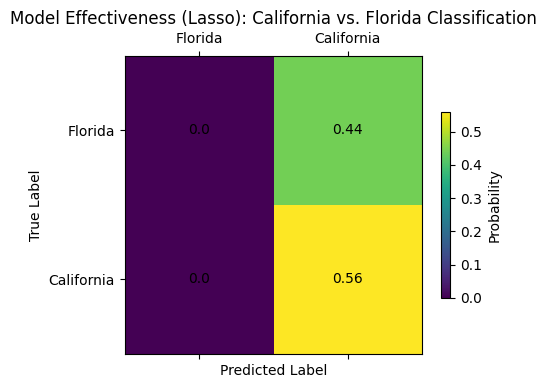

In [340]:
cm = confusion_matrix(y_test, y_pred = y_pred_l)
labels = ["Florida", "California"]

t = np.sum(cm)
cm_prob = np.round(cm/t,2)
plt.matshow(cm_prob)
cb = plt.colorbar(shrink=0.5)
plt.title("Model Effectiveness (Lasso): California vs. Florida Classification")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
cb.set_label("Probability")
plt.xticks([0,1], labels)
plt.yticks([0,1], labels)


for i in range(len(labels)):
    for j in range(len(labels)):
        plt.text(j,i,cm_prob[i,j], ha='center', va='center', color='black')

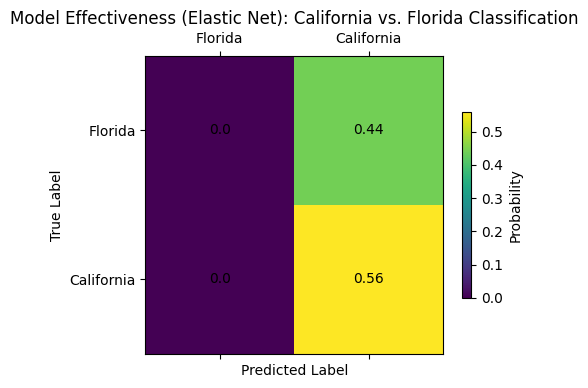

In [341]:
cm = confusion_matrix(y_test, y_pred = y_pred_e)
labels = ["Florida", "California"]

t = np.sum(cm)
cm_prob = np.round(cm/t,2)
plt.matshow(cm_prob)
cb = plt.colorbar(shrink=0.5)
plt.title("Model Effectiveness (Elastic Net): California vs. Florida Classification")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
cb.set_label("Probability")
plt.xticks([0,1], labels)
plt.yticks([0,1], labels)


for i in range(len(labels)):
    for j in range(len(labels)):
        plt.text(j,i,cm_prob[i,j], ha='center', va='center', color='black')

In [342]:
#########################
# Classification report #
#########################
target_names = ['Florida', 'California'] # 0 = Florida, 1 = California

report_dict_r = classification_report(y_test, y_pred_r, target_names=target_names, output_dict=True)

report_df_r = pd.DataFrame(report_dict_r)
report_df_r.head(10)

C:\Users\gigan\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\gigan\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\gigan\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_clas

,Florida,California,accuracy,macro avg,weighted avg
precision,0.0,0.555556,0.555556,0.277778,0.308642
recall,0.0,1.000000,0.555556,0.500000,0.555556
f1-score,0.0,0.714286,0.555556,0.357143,0.396825
support,4.0,5.000000,0.555556,9.000000,9.000000


Text(0.5, 1.0, 'Ridge Loss')

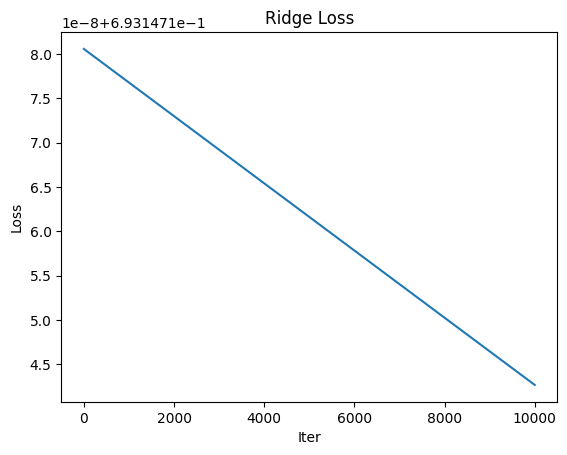

In [343]:
plt.plot(L_r)
plt.xlabel('Iter')
plt.ylabel('Loss')
plt.title('Ridge Loss')

In [344]:
report_dict_l = classification_report(y_test, y_pred_l, target_names=target_names, output_dict=True)

report_df_l = pd.DataFrame(report_dict_l)
# report_df_l.to_csv("report_lasso.csv")
report_df_l.head()

C:\Users\gigan\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\gigan\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\gigan\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_clas

,Florida,California,accuracy,macro avg,weighted avg
precision,0.0,0.555556,0.555556,0.277778,0.308642
recall,0.0,1.000000,0.555556,0.500000,0.555556
f1-score,0.0,0.714286,0.555556,0.357143,0.396825
support,4.0,5.000000,0.555556,9.000000,9.000000


Text(0.5, 1.0, 'Lasso Loss')

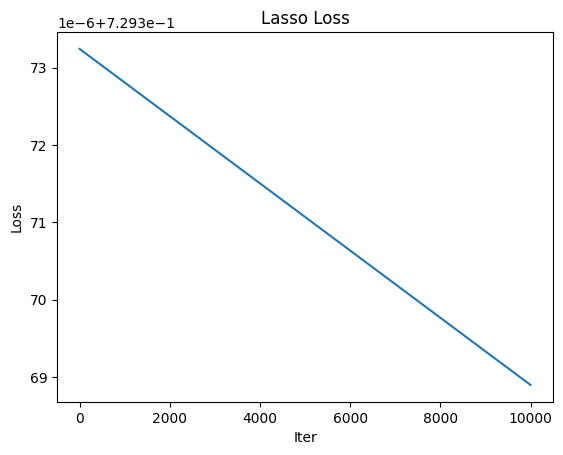

In [345]:
plt.plot(L_l)
plt.xlabel('Iter')
plt.ylabel('Loss')
plt.title('Lasso Loss')

In [346]:
report_dict_e = classification_report(y_test, y_pred_e, target_names=target_names, output_dict=True)

report_df_e = pd.DataFrame(report_dict_e)
# report_df_e.to_csv("report_elastic.csv")
report_df_e.head()

C:\Users\gigan\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\gigan\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\gigan\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_clas

,Florida,California,accuracy,macro avg,weighted avg
precision,0.0,0.555556,0.555556,0.277778,0.308642
recall,0.0,1.000000,0.555556,0.500000,0.555556
f1-score,0.0,0.714286,0.555556,0.357143,0.396825
support,4.0,5.000000,0.555556,9.000000,9.000000


Text(0.5, 1.0, 'Elastic Net Loss')

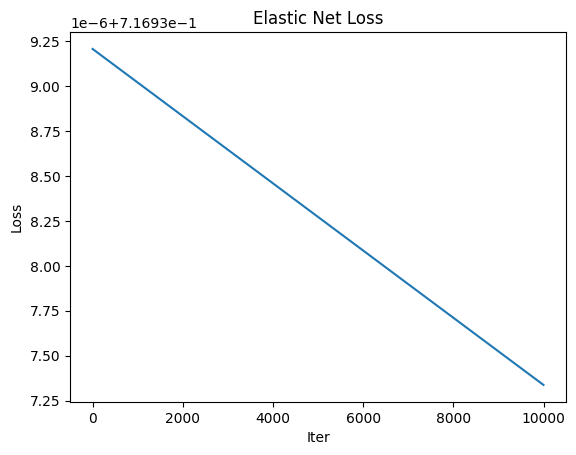

In [347]:
plt.plot(L_e)
plt.xlabel('Iter')
plt.ylabel('Loss')
plt.title('Elastic Net Loss')

***ROC curve***

Implement a function for producing the Receiver Operating Characteristic (ROC) curve.

Given true and predicted values, plot the ROC curve using your implemented function.

In [348]:
def ROC(prob, y_te):

    prob_b = np.append(prob, 1.1)
    prob_b = np.append(prob_b, -0.1)
    thresholds = np.unique(prob_b)
    thresholds = np.sort(thresholds)
    tpr_list = []
    fpr_list = []

    for i in range(len(thresholds)):
        y_pr = (prob > thresholds[i]).astype(int)
        cm_roc = confusion_matrix(y_te, y_pr)
        TPR = cm_roc[1,1]/(cm_roc[1,1]+cm_roc[1,0])
        FPR = cm_roc[0,1]/(cm_roc[0,1]+cm_roc[0,0])
        tpr_list.append(TPR)
        fpr_list.append(FPR)

    return tpr_list, fpr_list


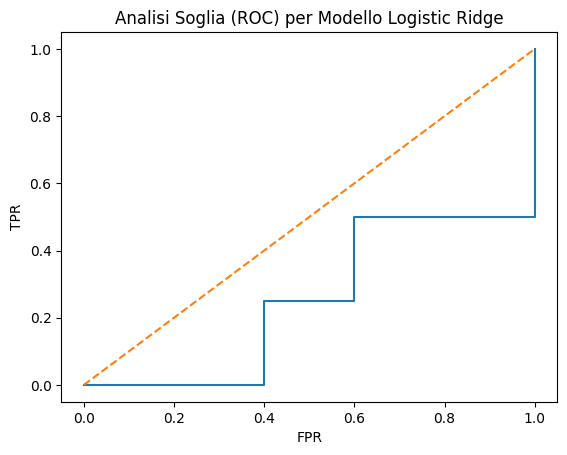

In [349]:
tpr_r, fpr_r = ROC(prob_r, y_test)

plt.ylabel("TPR")
plt.xlabel("FPR")
plt.title("Analisi Soglia (ROC) per Modello Logistic Ridge")
plt.plot(tpr_r, fpr_r)
plt.plot([0, 1], [0, 1], linestyle = "dashed")

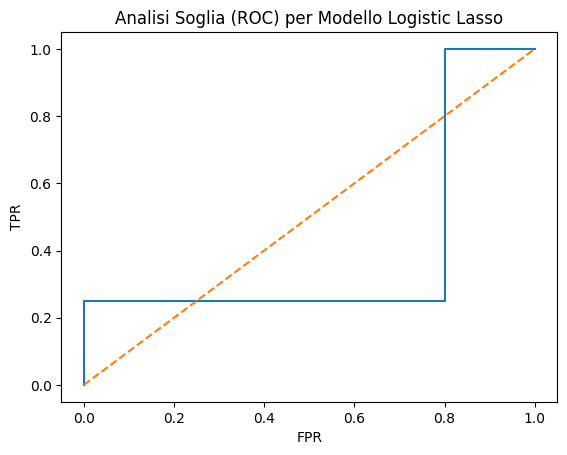

In [350]:
tpr_l, fpr_l = ROC(prob_l, y_test)

plt.ylabel("TPR")
plt.xlabel("FPR")
plt.title("Analisi Soglia (ROC) per Modello Logistic Lasso")
plt.plot(tpr_l, fpr_l)
plt.plot([0, 1], [0, 1], linestyle = "dashed")

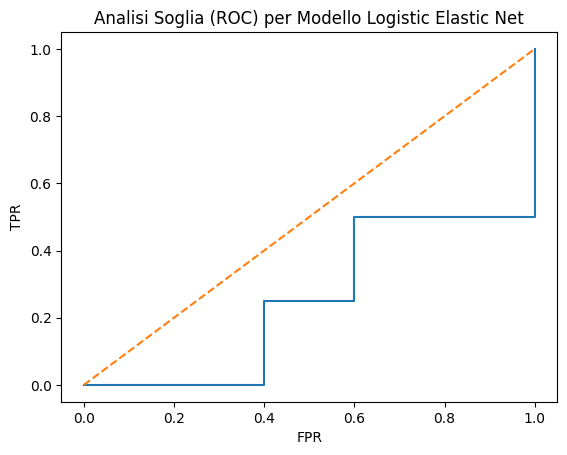

In [351]:
tpr_e, fpr_e = ROC(prob_e, y_test)

plt.ylabel("TPR")
plt.xlabel("FPR")
plt.title("Analisi Soglia (ROC) per Modello Logistic Elastic Net")
plt.plot(tpr_e, fpr_e)
plt.plot([0, 1], [0, 1], linestyle = "dashed")